# Multi-objective optimization

This notebook demonstrates how to perform **multi-objective** Bayesian optimization using the MO-SEGO (Multi-Objective Super Efficient Global Optimization) framework. Constrained and multi-fidelity optimization are also supported in the multi-objective framework.

In multi-objective optimization, we are interested in minimizing multiple $n$ objectives with respect to constraints $\boldsymbol{g}$ and $\boldsymbol{h}$ (if applicable).

$$
\min_{\boldsymbol{x} \in \Omega} \{ \boldsymbol{f}(\boldsymbol{x}) := [ f_1(\boldsymbol{x}), \; f_1(\boldsymbol{x}), \; \dots, \; f_n(\boldsymbol{x})]  \quad \text{s.t.} \quad \boldsymbol{g}(\boldsymbol{x}) \leq \boldsymbol{0} \; \text{and} \; \boldsymbol{h}(\boldsymbol{x}) = \boldsymbol{0}\}
$$


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from smt.sampling_methods import LHS
from smt_optim.core import Driver, ObjectiveConfig, ConstraintConfig, DriverConfig, Problem

from smt_optim.surrogate_models.smt import SmtGPX,SmtAutoModel

from smt_optim.acquisition_strategies.multiobj import MOSEGO
from smt_optim.acquisition_functions.multi_obj import init_mpi
from smt_optim.utils.multi_obj import get_pareto_front, get_pf_from_dataset

from smt_optim.benchmarks.registry import get_problem
from smt_optim.utils.plot_2d import get_plot2d_data

from smt_optim.utils.multi_obj import PymooStateWrapper
from smt_optim.benchmarks.base import PymooWrapper
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.optimize import minimize


## Multi-objective optimization

The following example illustrates how to find the ZDT1's pareto front using the MO-SEGO framework. The code cell below imports the test problem using the `get_problem` method and plots both objective. The ZDT1 is defined as follow:

$$
\begin{aligned}
f_1(\boldsymbol x) & = x_1\\
f_2(\boldsymbol x) & = g(\boldsymbol x) h(f_1(\boldsymbol x), \; g(\boldsymbol x))
\end{aligned}
$$

where $d=2$ is the number of variable, $g(\boldsymbol x) = 1 + \frac{9}{d - 1}\sum_{i=2}^{d}x_i$, and $h(f_1, \; g) = 1 - \sqrt{f_1/g}$.



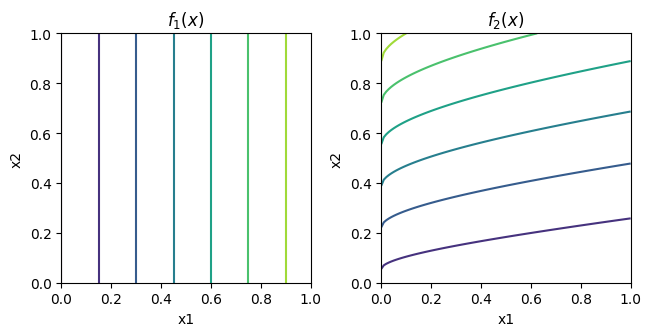

In [2]:

problem = get_problem("ZDT1")

problem.set_dim(2)

x1 = np.linspace(0, 1, 101)
x2 = np.linspace(0, 1, 101)

XX, YY = np.meshgrid(x1, x2)

data = np.vstack((XX.ravel(), YY.ravel())).T
f1 = np.empty(data.shape[0])
f2 = np.empty(data.shape[0])

for i in range(data.shape[0]):
    f1[i] = problem.f1(data[i, :])
    f2[i] = problem.f2(data[i, :])

F1 = f1.reshape(XX.shape)
F2 = f2.reshape(XX.shape)

fig, ax = plt.subplots(1, 2, layout="constrained")
ax[0].set_title(r"$f_1(x)$")
ax[0].contour(XX, YY, F1)
ax[1].set_title(r"$f_2(x)$")
ax[1].contour(XX, YY, F2)

for idx in range(2):
    ax[idx].set_xlabel("x1")
    ax[idx].set_ylabel("x2")
    ax[idx].set_aspect("equal")

plt.show()


### Starting the optimization

The code cell shows how to initialize both objective, the problem configuration, and the driver configuration. The driver is initialized with the `MOSEGO` acquisition strategy**, which is designed for multiple objective optimization. The **Minimum Probability of Improvement (MPI)** acquisition function is used in this example.


In [3]:
# initialize the first objective configuration
obj1_config = ObjectiveConfig(
    [problem.f1],
    type="minimize",
    surrogate=SmtGPX,
)

# initialize the second objective configuration
obj2_config = ObjectiveConfig(
    [problem.f2],
    type="minimize",
    surrogate=SmtGPX,
)

# initialize the problem configuration
prob_definition = Problem(
    obj_configs=[obj1_config, obj2_config],
    design_space=problem.bounds,            # problem bounds
)

nt_init = 5

# initialize the driver
opt_config = DriverConfig(
    max_iter = 30,
    nt_init = nt_init,
    verbose = True,
    scaling = True,
    seed=0,
)

driver = Driver(prob_definition, opt_config, MOSEGO, strategy_kwargs={"acq_func": init_mpi, "n_start": 40, "sp_method": "SLSQP"})

# starts the optimization process
state = driver.optimize()


          iter         budget             HV        spacing       fidelity        gp_time       acq_time
             0              5    4.19380e+00    1.51008e+00            nan            nan            nan
             1              6    4.52256e+00    1.61580e+00              1          0.059          0.056
             2              7    5.43176e+00    0.00000e+00              1          0.059          0.055
             3              8    5.55218e+00    2.37783e+00              1          0.069          0.046
             4              9    5.84665e+00    8.17766e-03              1          0.071          0.065
             5             10    5.86907e+00    2.82211e-01              1          0.078          0.086
             6             11    5.91253e+00    2.38906e-01              1          0.094          0.075
             7             12    5.92523e+00    2.72115e-01              1          0.127          0.110
             8             13    5.93492e+00    2.66067

### Plotting the results

The code cell below extracts the pareto front from the final DOE using the `get_pf_from_dataset` method. The figure shows the final DOE, the initial DOE, the DOE samples forming the pareto front, and the true pareto front.


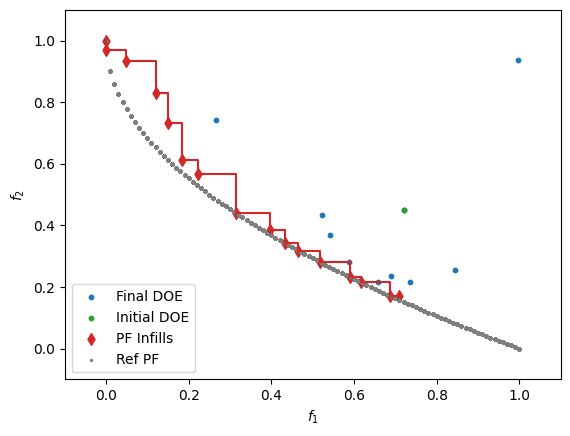

In [4]:

# ======= Optimization Pareto Front =======
data = driver.state.dataset.export_as_dict()
obj = data["obj"]

obj_par = get_pf_from_dataset(state.dataset)

# ======= Solution Pareto Front =======
x1 = np.linspace(0, 1, 101)
x2 = np.linspace(0, 0, 101)

XX, YY = np.meshgrid(x1, x2)

data = np.vstack((XX.ravel(), YY.ravel())).T
f1 = np.empty(data.shape[0])
f2 = np.empty(data.shape[0])

for i in range(data.shape[0]):
    f1[i] = problem.f1(data[i, :])
    f2[i] = problem.f2(data[i, :])

F1 = f1.reshape(XX.shape)
F2 = f2.reshape(XX.shape)

ref_pareto = get_pareto_front(np.vstack((f1, f2)).T)

# ======= Plot optimization and solution pareto front =======
fig, ax = plt.subplots()

ax.scatter(obj[:, 0], obj[:, 1], 10, color="C0", label="Final DOE")
ax.scatter(obj[:nt_init, 0], obj[:nt_init, 1], 10, color="C2", label="Initial DOE")
ax.scatter(obj_par[:, 0], obj_par[:, 1], marker="d", color="C3", label="PF Infills")

sorted_idx = np.argsort(obj_par[:, 0])
obj_par = obj_par[sorted_idx, :]

# PF obtained through optimization
ax.step(obj_par[:, 0], obj_par[:, 1], where="post", color="C3", zorder=20)

# Solution PF
ax.scatter(ref_pareto[:, 0], ref_pareto[:, 1], 2, color="C7", zorder=10, label="Ref PF")

ax.set_xlabel(r"$f_1$")
ax.set_ylabel(r"$f_2$")

ax.set_xlim((-0.1, 1.1))
ax.set_ylim((-0.1, 1.1))
ax.legend()
plt.show()


## Constrained multi-objective optimization

The following example illustrates how to find the pareto front when subjected to constraints. The `get_problem` method is used to import the BNH test problem, which is defined as follow:

$$
\begin{aligned}
f_1(\boldsymbol x) & = 4x_1^2 + 4x_2^2\\
f_2(\boldsymbol x) & = (x_1 - 5)^2 + (x_2 - 5)^2\\
g_1(\boldsymbol x) & = (x_1 - 5)^2 + x_2^2 - 25\\
g_2(\boldsymbol x) & = -(x_1 - 8)^2 - (x_2^2+3)^2 + 7.7.
\end{aligned}
$$


In [5]:
problem = get_problem("BNH")


In [6]:

obj1_config = ObjectiveConfig(
    [problem.objective[0]],
    type="minimize",
    surrogate=SmtGPX,
)

obj2_config = ObjectiveConfig(
    [problem.objective[1]],
    type="minimize",
    surrogate=SmtGPX,
)

cstr1_config = ConstraintConfig(
    [problem.constraints[0]],
    upper=0.,
    surrogate=SmtGPX,
)

cstr2_config = ConstraintConfig(
    [problem.constraints[1]],
    upper=0.,
    surrogate=SmtGPX,
)

prob_definition = Problem(
    obj_configs=[obj1_config, obj2_config],
    cstr_configs=[cstr1_config, cstr2_config],
    design_space=problem.bounds,            # problem bounds
)

nt_init = 5

opt_config = DriverConfig(
    max_iter = 10,
    nt_init = nt_init,
    # xt_init = doe,
    verbose = True,
    scaling = True,
    seed=0,
)

driver = Driver(prob_definition, opt_config, MOSEGO, strategy_kwargs={"acq_func": init_mpi, "n_start": 40, "sp_method": "SLSQP"})

state = driver.optimize()


          iter         budget             HV        spacing       fidelity        gp_time       acq_time
             0              5    1.12241e+03    3.97964e+00            nan            nan            nan
             1              6    1.14717e+03    7.00315e+00              1          0.097          0.190
             2              7    1.28411e+03    6.39639e+00              1          0.114          0.078
             3              8    1.28411e+03    6.39639e+00              1          0.186          0.089
             4              9    1.31007e+03    2.47987e+00              1          0.197          0.123
             5             10    1.31007e+03    2.17686e+00              1          0.175          0.103
             6             11    1.34451e+03    1.78729e+00              1          0.226          0.088
             7             12    1.35956e+03    2.50068e+00              1          0.188          0.091
             8             13    1.36624e+03    2.54545

In [7]:
pareto_front = get_pf_from_dataset(state.dataset)

obj = state.dataset.export_as_dict()["obj"]

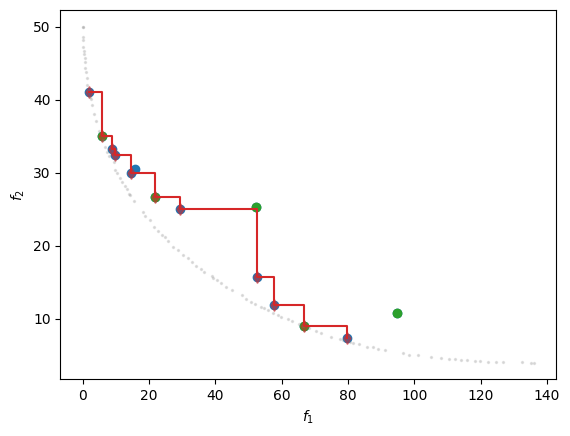

In [8]:
# ======= Optimization Pareto Front =======
# dataset = driver.dataset
data = driver.state.dataset.export_as_dict()
obj = data["obj"]
rscv = data["rscv"]
obj = obj[rscv <= 1e-4, :]
# obj_par = get_pareto_front(obj)

pareto_front = get_pf_from_dataset(state.dataset, ctol=0.)

# ======= Solution Pareto Front =======
pymoo_prob = PymooWrapper(problem)

algorithm = NSGA2(pop_size=100, seed=1)
res = minimize(pymoo_prob, algorithm, ("n_gen", 100), seed=1)

# ======= Plot optimization and solution pareto front =======
fig, ax = plt.subplots()

ax.scatter(obj[:, 0], obj[:, 1])
ax.scatter(obj[:nt_init, 0], obj[:nt_init, 1], color="C2")

sorted_idx = np.argsort(pareto_front[:, 0])
pareto_front = pareto_front[sorted_idx, :]

# PF obtained through optimization
ax.step(pareto_front[:, 0], pareto_front[:, 1], where="post", color="C3", zorder=20)
ax.scatter(pareto_front[:, 0], pareto_front[:, 1], marker="d", color="C3", alpha=0.5)

# Solution PF
# ax.scatter(F1, F2, 2, color="C7", alpha=0.2, zorder=10)
ax.scatter(res.F[:, 0], res.F[:, 1], 2, color="C7", alpha=0.2, zorder=10)
# ax.scatter(multi_obj_ref[0], multi_obj_ref[1], 100, marker="x", color="C8", zorder=100)

ax.set_xlabel(r"$f_1$")
ax.set_ylabel(r"$f_2$")

# ax.set_xlim((-0.1, 1.1))
# ax.set_ylim((-0.1, 1.1))


plt.show()

### Applying NSGA-II (pymoo) on the surrogate models

Users can use the `PymooStateWrapper` to convert a state object into a `Pymoo` `Problem` object. Below, the NSGA-II algorithm is applied on the objective and constraint models to find a predicted pareto-front.


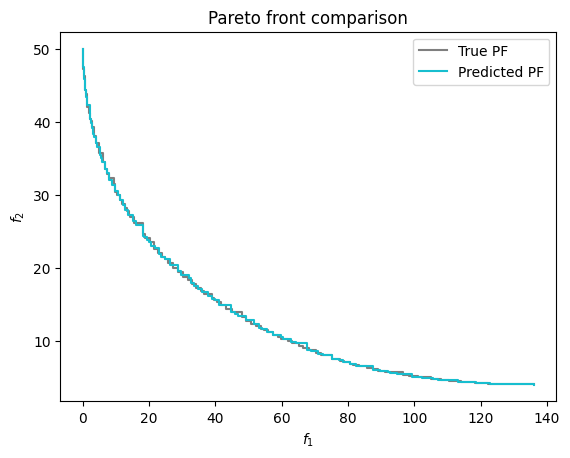

In [9]:

# Create a pymoo problem object from the SMT-Optim state object
pymoo_pred = PymooStateWrapper(state)

fig, ax = plt.subplots()

# Pareto front obtained with pymoo on the test problem directly
sorted_idx = np.argsort(res.F[:, 0])
res.F = res.F[sorted_idx, :]
ax.step(res.F[:, 0], res.F[:, 1], color="C7", where="post", label="True PF")

# Pareto front obtained with pymoo on using the surrogate models with the final DOE
res_pred = minimize(pymoo_pred, algorithm, ("n_gen", 100), seed=1)
sorted_idx = np.argsort(res_pred.F[:, 0])
res_pred.F = res_pred.F[sorted_idx, :]
ax.step(res_pred.F[:, 0], res_pred.F[:, 1], color="C9", where="post", label="Predicted PF")

ax.legend()
ax.set_title("Pareto front comparison")
ax.set_xlabel(r"$f_1$")
ax.set_ylabel(r"$f_2$")
plt.show()


## Constrained, multi-fidelity, and multi-objective optimization

The following example demonstrates how to find the pareto-front of a constrained multi-objective problem for which low-fidelity approximation exists.


In [10]:
problem = get_problem("DTLZ5")
problem.set_dim(4)


In [11]:
obj_config = ObjectiveConfig(
    problem.objective[0],
    type="minimize",
    surrogate=SmtAutoModel,
)

obj_config2 = ObjectiveConfig(
    problem.objective[1],
    type="minimize",
    surrogate=SmtAutoModel,
)

cstr_config = ConstraintConfig(
    problem.constraints[0],
    upper=0.,
    surrogate=SmtAutoModel,
)

prob_definition = Problem(
    obj_configs=[obj_config, obj_config2],
    cstr_configs=[cstr_config],
    design_space=problem.bounds,            # problem bounds
    costs=[0.2, 1.],
)

nt_init = 12

opt_config = DriverConfig(
    max_iter = 50,
    nt_init = nt_init,
    verbose = True,
    scaling = True,
    seed=0,
)

# np.seterr(all="raise")

# driver = Driver(prob_definition, opt_config, MultiObj, strategy_kwargs={"acq_func": init_mpi, "n_start": 1000, "sp_method": None})
driver = Driver(prob_definition, opt_config, MOSEGO, strategy_kwargs={"acq_func": init_mpi, "n_start": 20, "sp_method": "SLSQP",})

In [12]:
state = driver.optimize()

          iter         budget             HV        spacing       fidelity        gp_time       acq_time
             0         16.800    2.01117e-01    0.00000e+00            nan            nan            nan
             1         17.000    2.01117e-01    0.00000e+00              1          2.216          0.967
             2         17.200    2.01117e-01    0.00000e+00              1          2.184          1.512
             3         17.400    2.01117e-01    0.00000e+00              1          2.328          1.564
             4         17.600    2.01117e-01    0.00000e+00              1          2.071          0.461
             5         17.800    2.01117e-01    0.00000e+00              1          1.664          1.178
             6         18.000    2.01117e-01    0.00000e+00              1          2.577          0.843
             7         18.200    2.01117e-01    0.00000e+00              1          2.202          1.025
             8         18.400    2.01117e-01    0.00000

/home/corde/smt-optim/src/smt_optim/core/driver.py:472: UserWarning: Infill point [1. 1. 1. 0.] already in training data. L2 = 1.6911801396061684e-12
  warnings.warn(f"Infill point {infills[lvl][idx, :]} already in training data. L2 = {np.min(l2_norms)}")


            22         27.200    2.53121e-01    1.27363e-01              2          1.795          1.497
            23         27.400    2.53121e-01    1.27363e-01              1          2.270          2.108
            24         27.600    2.53121e-01    1.27363e-01              1          1.838          1.904
            25         27.800    2.53121e-01    1.27363e-01              1          1.688          1.503
            26         28.000    2.53121e-01    1.27363e-01              1          1.976          1.116
            27         29.200    2.53134e-01    1.23740e-01              2          1.869          1.144
            28         29.400    2.53134e-01    1.23740e-01              1          1.688          1.508
            29         29.600    2.53134e-01    1.23740e-01              1          1.829          1.784
          iter         budget             HV        spacing       fidelity        gp_time       acq_time
            30         29.800    2.53134e-01    1.23740

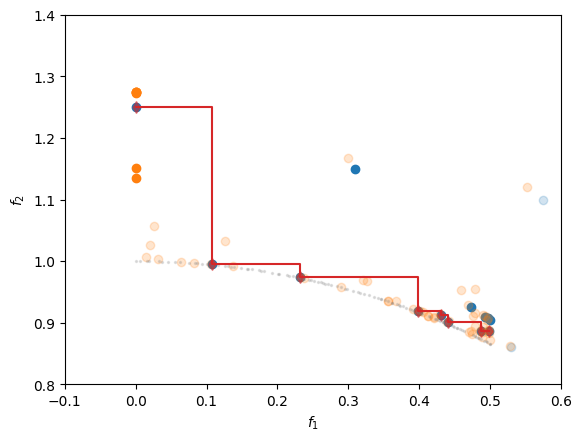

In [13]:

# ======= Optimization Pareto Front =======
# dataset = driver.dataset
data = driver.state.dataset.export_as_dict()
obj = data["obj"]
rscv = data["rscv"]
feas_mask = rscv <= 1e-4
fid_mask = data["fidelity"] == 1
# obj = obj[rscv <= 1e-4, :]
# obj_par = get_pareto_front(obj)

pareto_front = get_pf_from_dataset(state.dataset)

# ======= Solution Pareto Front =======
pymoo_prob = PymooWrapper(problem)

algorithm = NSGA2(pop_size=100, seed=1)
res = minimize(pymoo_prob, algorithm, ("n_gen", 30), seed=1)



# ======= Plot optimization and solution pareto front =======
fig, ax = plt.subplots()

ax.scatter(obj[:, 0][feas_mask & fid_mask], obj[:, 1][feas_mask & fid_mask])
ax.scatter(obj[:, 0][~feas_mask & fid_mask], obj[:, 1][~feas_mask & fid_mask], color="C0", alpha=0.2)
ax.scatter(obj[:, 0][feas_mask & ~fid_mask], obj[:, 1][feas_mask & ~fid_mask], color="C1")
ax.scatter(obj[:, 0][~feas_mask & ~fid_mask], obj[:, 1][~feas_mask & ~fid_mask], color="C1", alpha=0.2)
# ax.scatter(obj[:nt_init, 0][fid_mask], obj[:nt_init, 1][fid_mask], color="C2")

sorted_idx = np.argsort(pareto_front[:, 0])
pareto_front = pareto_front[sorted_idx, :]

# PF obtained through optimization
ax.step(pareto_front[:, 0], pareto_front[:, 1], where="post", color="C3", zorder=20)
ax.scatter(pareto_front[:, 0], pareto_front[:, 1], marker="d", color="C3", alpha=0.5)

# Solution PF
# ax.scatter(F1, F2, 2, color="C7", alpha=0.2, zorder=10)
ax.scatter(res.F[:, 0], res.F[:, 1], 2, color="C7", alpha=0.2, zorder=10)

ax.set_xlabel(r"$f_1$")
ax.set_ylabel(r"$f_2$")

ax.set_xlim((-0.1, 0.6))
ax.set_ylim((0.8, 1.4))

plt.show()
